#### 0. Importar librerias

In [1]:
import pandas as pd
import sklearn
import missingno as mo
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

#### 1. Cargar e inspeccionar los datos

In [2]:
df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')

C:\Users\Uxue Duran Nuño\AppData\Local\Temp\ipykernel_11764\924406895.py:1: DtypeWarning: Columns (56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')


In [3]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,cluster,cluster_0,cluster_1,cluster_2,cluster_3
0,2022-11-26 16:10:00,2023-01-01,2023-01-02 12:00:00,36,1,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
1,2022-12-21 17:27:00,2023-01-01,2023-01-10 12:00:00,11,9,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
2,2022-09-21 19:46:00,2023-01-01,2023-01-07 12:00:00,102,6,January,Sunday,2,4,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
3,2022-09-24 12:09:00,2023-01-01,2023-01-02 12:00:00,99,1,January,Sunday,2,2,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
4,2022-10-18 07:12:00,2023-01-01,2023-01-02 12:00:00,75,1,January,Sunday,4,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0


In [4]:
df.columns

Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time', 'ciudad', 'mes_cancelacion',
       'estacion_cancelacion', 'mes_estancia', 'estacion_estancia',
       'mes_reserva', 'estacion_reserva', 'dia_semana_reserva',
       'dia_semana_reserva_nombre', 'dia_semana_cancelacion',
       'dia_semana_cancelacion_nombre', 'dia_sem

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52004 entries, 0 to 52003
Data columns (total 87 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   booked_at                       52004 non-null  object 
 1   checkin_time                    52004 non-null  object 
 2   checkout_time                   52004 non-null  object 
 3   lead_time                       52004 non-null  int64  
 4   lenght_of_stay                  52004 non-null  int64  
 5   checkin_month                   52004 non-null  object 
 6   checkin_day                     52004 non-null  object 
 7   adult_count                     52004 non-null  int64  
 8   child_count                     52004 non-null  int64  
 9   origin                          52004 non-null  object 
 10  travel_agency_name              52004 non-null  object 
 11  requested_category              52004 non-null  object 
 12  requested_category_name         

In [6]:
df.shape

(52004, 87)

<Axes: >

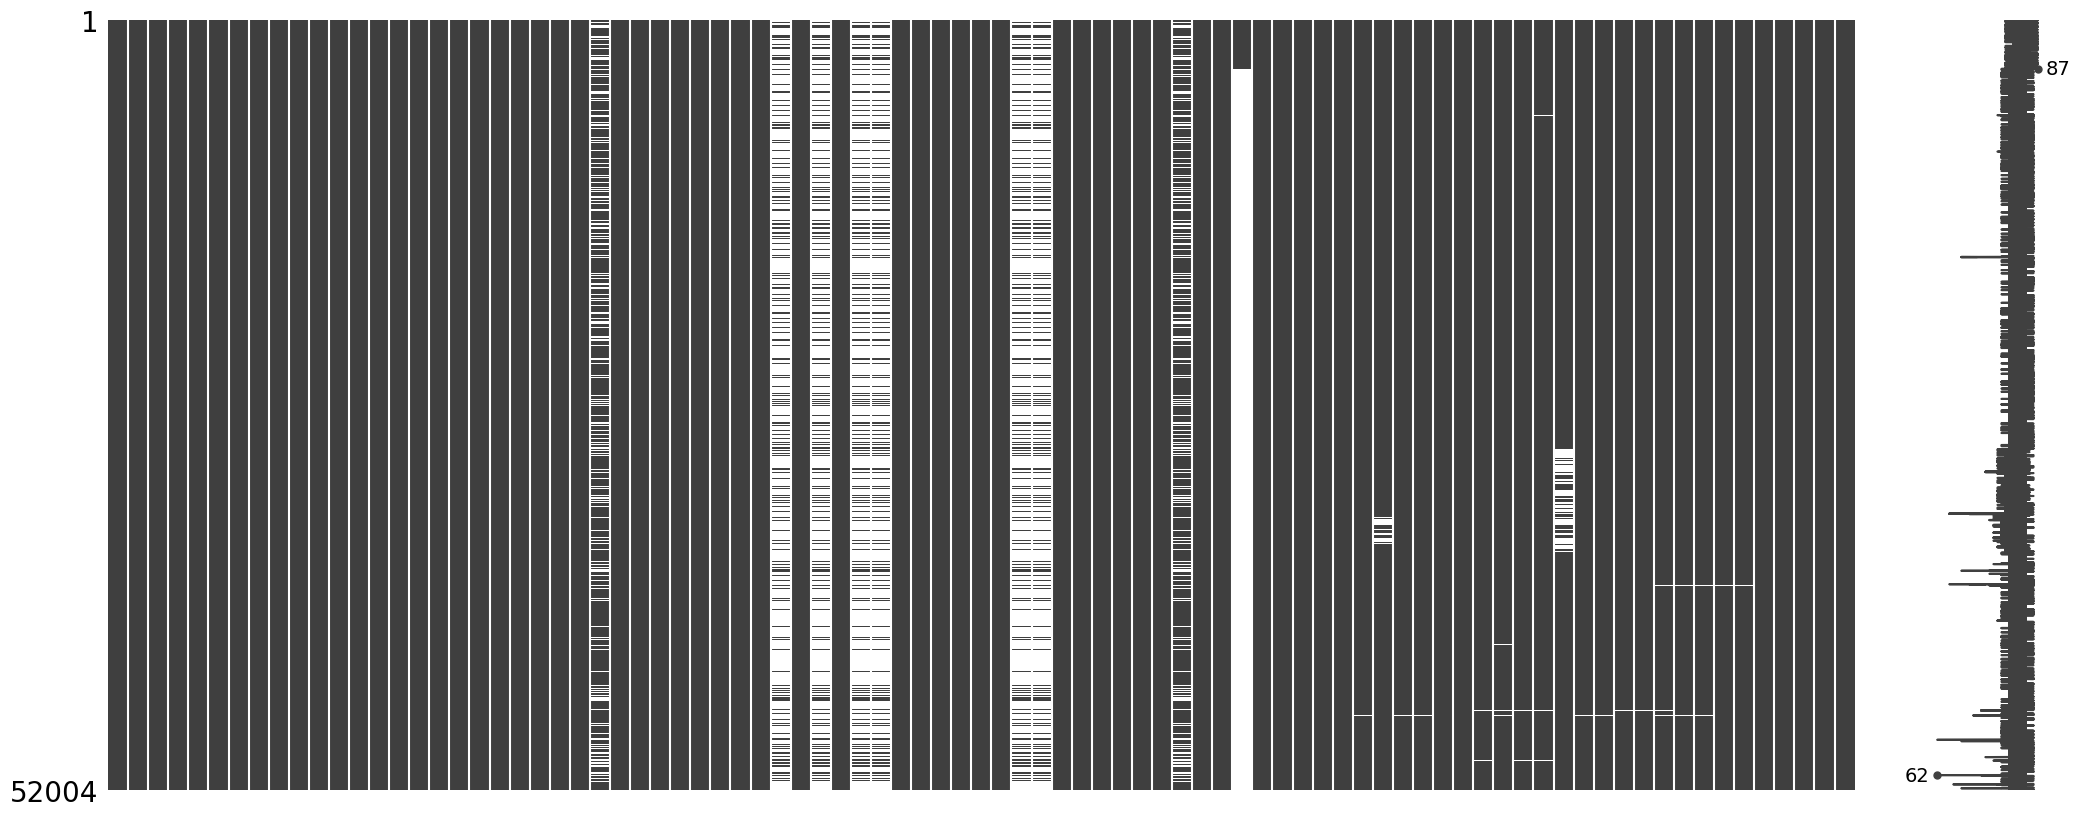

In [7]:
mo.matrix(df)

#### 3. Seleccion de variables relevantes para modelado

In [8]:
# Criterio para la seleccion de variables para regresion:
#    1. Primero se seleccionan únicamente variables disponibles en el momento de la reserva y que, desde el punto de vista de negocio, puedan influir en la probabilidad de cancelación.
#    2. Después mirar la relacion entre cada una de ellas con el target:
#       - para las numericas con corr
#       - para las binarias media del target
#       - para las categoricas la tasa de cancelacion por grupo (si se acaba seleccionando pasar a dummies)
#    3. Entre las seleccionadas, eliminar las que tengan alta correlacion entre ellas

In [ ]:
# Definir el target
df['target'] = (df['status'] == 'cancelled').astype(int)

df['target'].value_counts(normalize=True) # 76% no cancelan

target
0    0.764018
1    0.235982
Name: proportion, dtype: float64

In [43]:
# 1. Seleccion conceptual
vars_numericas = ['lead_time', 'lenght_of_stay', 
                  'adult_count', 'child_count',
                  'available_units', 'reservation_net_value', 
                  'total_adr', 'product_count', 
                  'recurrence', 'ratio_cancelacion_mes_estancia', 
                  'tmed', 'prec', 'sol']

vars_binarias = ['zona_roja','es_finde',
                 'es_festivo', 'cluster_1',
                 'cluster_2', 'cluster_3']

vars_categoricas = ['origin', 'business_segment',
                    'rate_type', 'requested_category', 
                    'asset_type', 'brand', 'ciudad']

In [44]:
#2. Analisis de relacion con el target

# 2.1 Numericas
corr_num = (
    df[vars_numericas + ['target']]
    .corr()['target']
    .sort_values(ascending=False)
    .drop('target'))

print(corr_num)


lead_time                         0.220967
lenght_of_stay                    0.131798
adult_count                       0.101525
reservation_net_value             0.086955
total_adr                         0.053947
ratio_cancelacion_mes_estancia    0.025349
prec                              0.014982
child_count                      -0.006512
available_units                  -0.012650
sol                              -0.021953
tmed                             -0.026100
recurrence                       -0.046127
product_count                    -0.135070
Name: target, dtype: float64


In [45]:
# Nos quedamos con |corr| >= 0.05 y 1, porque aun que sean correlaciones debiles, al tratarse de cancelaciones y de comportamiento humano,
# 0.10 ya es bastante y 0.05 puede ser útil combinado con otras variables
vars_numericas_filtradas = corr_num[corr_num.abs() >= 0.05].index.tolist()
print(vars_numericas_filtradas)

['lead_time', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'total_adr', 'product_count']


In [46]:
# 2.2 Binarias
for var in vars_binarias:
    print(f'\n{var}')
    print(df.groupby(var)['target'].mean())


zona_roja
zona_roja
0    0.230250
1    0.249437
Name: target, dtype: float64

es_finde
es_finde
0    0.229869
1    0.251552
Name: target, dtype: float64

es_festivo
es_festivo
0    0.236251
1    0.227094
Name: target, dtype: float64

cluster_1
cluster_1
0    0.245429
1    0.196279
Name: target, dtype: float64

cluster_2
cluster_2
0    0.230342
1    0.259020
Name: target, dtype: float64

cluster_3
cluster_3
0    0.232667
1    0.241563
Name: target, dtype: float64


In [53]:
# Para las variables binarias un umbral razonable de diferencia puede ser mayor que 0.02
vars_binarias_filtradas = []

for var in vars_binarias:
    medias = df.groupby(var)['target'].mean()
    diff = abs(medias[1] - medias[0])
    if diff > 0.02:
        vars_binarias_filtradas.append(var)

print(vars_binarias_filtradas)

['es_finde', 'cluster_1', 'cluster_2']


In [ ]:
# 2.3 Categoricas
for var in vars_categoricas:
    print(f'\n{var}')
    display(
        df.groupby(var)['target']
        .mean()
        .sort_values(ascending=False)
        .head(10))


origin


origin
email              0.420612
telephone          0.302963
in_person          0.301370
channel_manager    0.240168
direct_channel     0.136554
Name: target, dtype: float64


business_segment


business_segment
Travel Individual      0.474332
Business Individual    0.440613
Mid Stay               0.365385
Travel Group           0.342903
MICE Group             0.321063
MICE Individual        0.276471
Leisure Group          0.236181
Leisure Individual     0.219563
Business Group         0.149533
Name: target, dtype: float64


rate_type


...

asset_type
apartment     0.241563
aparthotel    0.240264
hostel        0.228008
Name: target, dtype: float64


brand


brand
koisi     0.259020
libere    0.230342
Name: target, dtype: float64


ciudad


ciudad
Valencia    0.285312
Granada     0.271475
Donosti     0.259020
Bilbao      0.253384
Vitoria     0.240264
Madrid      0.227432
Pamplona    0.219519
Málaga      0.217810
Córdoba     0.196279
Name: target, dtype: float64

In [ ]:
vars_categoricas_filtradas = []

for var in vars_categoricas:
    medias = df.groupby(var)['target'].mean()
    diff = medias.max() - medias.min()
    if diff >= 0.03:
        vars_categoricas_filtradas.append(var)

print(vars_categoricas_filtradas) 


['origin', 'business_segment', 'rate_type', 'requested_category', 'ciudad']


In [ ]:
# Ahora dummificar las variables categoricas seleccionadas